<a href="https://colab.research.google.com/github/ToluwaniOladeji/Formative-2---Principle-Component-Analysis/blob/main/PCA_Formative_2%5BPeer_Pair_Team_13%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

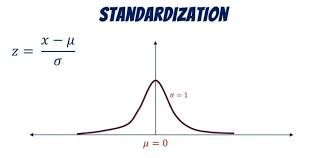


In [2]:
import numpy as np

filename = "conflict_data_cod.csv"
with open(filename, 'r', encoding='utf-8') as f:
    lines = f.readlines()

for i, line in enumerate(lines[:10]):
    print(f"Row {i}: {line[:100]}")

Row 0: data_id,iso,event_id_cnty,event_id_no_cnty,event_date,year,time_precision,event_type,sub_event_type,
Row 1: ,,#event+code,,#date+occurred,#date+year,,#event+type,,#group+name+first,#group+name+first+assoc,,#g
Row 2: 7173389,180,DRC18042,18042,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 3: 7173390,180,DRC18041,18041,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 4: 7173480,180,DRC18043,18043,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 5: 7173575,180,DRC18040,18040,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 6: 7173384,180,DRC18032,18032,2020-07-31,2020,1,Battles,Armed clash,Unidentified Armed Group (Democrati
Row 7: 7173386,180,DRC18035,18035,2020-07-31,2020,1,Battles,Armed clash,Mayi Mayi Militia (Nyatura),,3,Mili
Row 8: 7173393,180,DRC18031,18031,2020-07-31,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 9: 7173669,180,DRC18036,

In [3]:
print(f"Lines before dropping row 1: {len(lines)}")

# Safety check: only delete row 1 if it really is the HXL tag row
# (some of its leading fields are empty, so we look for a '#' tag inside it)
assert '#' in lines[1].split(',')[2], "Row 1 is not an HXL tag row - check the file!"
del lines[1]          # drop row 1, keep row 0 (header)

print(f"Lines after dropping row 1:  {len(lines)}")
for i, line in enumerate(lines[:3]):
    print(f"Row {i}: {line[:100]}")

Lines before dropping row 1: 17419
Lines after dropping row 1:  17418
Row 0: data_id,iso,event_id_cnty,event_id_no_cnty,event_date,year,time_precision,event_type,sub_event_type,
Row 1: 7173389,180,DRC18042,18042,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 2: 7173390,180,DRC18041,18041,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ


In [4]:
def parse_csv_line(text):
    """Split one CSV record into fields, respecting "quoted, fields" and "" escapes."""
    fields, cur, in_quotes, i = [], [], False, 0
    while i < len(text):
        ch = text[i]
        if in_quotes:
            if ch == '"':
                if i + 1 < len(text) and text[i + 1] == '"':   # escaped quote
                    cur.append('"'); i += 1
                else:
                    in_quotes = False
            else:
                cur.append(ch)
        else:
            if ch == '"':
                in_quotes = True
            elif ch == ',':
                fields.append(''.join(cur)); cur = []
            else:
                cur.append(ch)
        i += 1
    fields.append(''.join(cur))
    return fields

# Re-join records whose quoted field contains a line break (odd number of quotes so far)
records, buffer = [], ''
for line in lines:
    buffer += line
    if buffer.count('"') % 2 == 0:
        records.append(buffer.rstrip('\r\n'))
        buffer = ''

header = [h.strip().lstrip('\ufeff') for h in parse_csv_line(records[0])]
rows = []
for rec in records[1:]:
    vals = parse_csv_line(rec)
    if len(vals) == len(header):          # skip any malformed record
        rows.append(dict(zip(header, vals)))

print(f"Data rows after dropping HXL tag row: {len(rows)}")
print(f"Raw columns ({len(header)}): {header}")

Data rows after dropping HXL tag row: 17417
Raw columns (31): ['data_id', 'iso', 'event_id_cnty', 'event_id_no_cnty', 'event_date', 'year', 'time_precision', 'event_type', 'sub_event_type', 'actor1', 'assoc_actor_1', 'inter1', 'actor2', 'assoc_actor_2', 'inter2', 'interaction', 'region', 'country', 'admin1', 'admin2', 'admin3', 'location', 'latitude', 'longitude', 'geo_precision', 'source', 'source_scale', 'notes', 'fatalities', 'timestamp', 'iso3']


In [5]:
candidate_cols = ['fatalities', 'latitude', 'longitude', 'year', 'geo_precision',
                   'event_type', 'actor2']

n = len(rows)
print(f"{'Column':<15}{'Missing':>10}{'% Missing':>12}")
for c in candidate_cols:
    miss = sum(1 for r in rows if r[c].strip() == '')
    print(f"{c:<15}{miss:>10}{100*miss/n:>11.2f}%")

Column            Missing   % Missing
fatalities              0       0.00%
latitude                0       0.00%
longitude               0       0.00%
year                    0       0.00%
geo_precision           0       0.00%
event_type              0       0.00%
actor2               2395      13.75%


In [6]:
counts = {}
for r in rows:
    if r['actor2'].strip() != '':
        counts[r['actor2']] = counts.get(r['actor2'], 0) + 1

most_common = sorted(counts.items(), key=lambda kv: -kv[1])   # stable sort, highest count first
top4 = [name for name, _ in most_common[:4]]
print("Top 4 actor2 categories kept as-is:")
for name, cnt in most_common[:4]:
    print(f"  {name}  (n={cnt})")

def bucket_actor2(v):
    if v.strip() == '':
        return 'Unknown'          # imputed category for missing values
    elif v in top4:
        return v
    else:
        return 'Other'

for r in rows:
    r['actor2_has'] = 1.0 if r['actor2'].strip() != '' else 0.0  # missing-value indicator
    r['actor2_bucket'] = bucket_actor2(r['actor2'])              # imputed + bucketed category

Top 4 actor2 categories kept as-is:
  Civilians (Democratic Republic of Congo)  (n=6182)
  Military Forces of the Democratic Republic of Congo (2001-2019)  (n=1183)
  Police Forces of the Democratic Republic of Congo (2001-2019)  (n=574)
  Military Forces of the Democratic Republic of Congo (2019-)  (n=494)


In [7]:
feature_cols_numeric = ['fatalities', 'latitude', 'longitude', 'year',
                         'geo_precision', 'actor2_has']
# Non-numeric / categorical features -> label-encode
feature_cols_categorical = ['event_type', 'actor2_bucket']

encoders = {}
for c in feature_cols_categorical:
    uniques = sorted(set(r[c] for r in rows))
    encoders[c] = {v: i for i, v in enumerate(uniques)}
    print(f"{c} encoding -> {encoders[c]}")

X_list = []
for r in rows:
    vals = [float(r[c]) for c in feature_cols_numeric]
    vals += [float(encoders[c][r[c]]) for c in feature_cols_categorical]
    X_list.append(vals)

X_raw = np.array(X_list, dtype=np.float64)
feature_names = feature_cols_numeric + feature_cols_categorical
print(f"\nFinal feature matrix shape: {X_raw.shape}")
print(f"Feature names ({len(feature_names)}): {feature_names}")

event_type encoding -> {'Battles': 0, 'Explosions/Remote violence': 1, 'Protests': 2, 'Riots': 3, 'Strategic developments': 4, 'Violence against civilians': 5}
actor2_bucket encoding -> {'Civilians (Democratic Republic of Congo)': 0, 'Military Forces of the Democratic Republic of Congo (2001-2019)': 1, 'Military Forces of the Democratic Republic of Congo (2019-)': 2, 'Other': 3, 'Police Forces of the Democratic Republic of Congo (2001-2019)': 4, 'Unknown': 5}

Final feature matrix shape: (17417, 8)
Feature names (8): ['fatalities', 'latitude', 'longitude', 'year', 'geo_precision', 'actor2_has', 'event_type', 'actor2_bucket']


In [9]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
# standardized_data = None  # Do not use sklearn
# standardized_data[:5]  # Display the first few rows of standardized data

# Step 1: Standardize the data (numpy only)
mean = X_raw.mean(axis=0)
std = X_raw.std(axis=0)
standardized_data = (X_raw - mean) / std

print("standardized_data[:5]")
print(standardized_data[:5].round(4))
print("\nSanity check -> mean per feature (should be ~0):", standardized_data.mean(axis=0).round(6))
print("Sanity check -> std  per feature (should be ~1):", standardized_data.std(axis=0).round(6))

standardized_data[:5]
[[-0.1657  1.4577 -1.9866  1.0827 -0.6891 -2.5044 -0.1767  1.6255]
 [-0.1657  0.947   0.7201  1.0827 -0.6891 -2.5044 -0.1767  1.6255]
 [-0.1657 -0.4639  0.4274  1.0827 -0.6891 -2.5044 -0.1767  1.6255]
 [-0.1657 -0.2869  0.3629  1.0827 -0.6891 -2.5044 -0.1767  1.6255]
 [-0.1657  0.5147  0.4725  1.0827  1.1368  0.3993 -1.0858 -0.0439]]

Sanity check -> mean per feature (should be ~0): [-0.  0. -0.  0.  0. -0. -0.  0.]
Sanity check -> std  per feature (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [10]:
# # Step 3: Calculate the Covariance Matrix
# cov_matrix = None  # Calculate covariance matrix
# cov_matrix

n_samples = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n_samples - 1)

print(f"cov_matrix shape: {cov_matrix.shape}\n")
print(cov_matrix.round(3))

cov_matrix shape: (8, 8)

[[ 1.     0.017 -0.013 -0.133  0.01   0.066 -0.017 -0.046]
 [ 0.017  1.     0.303  0.017  0.114  0.097  0.039 -0.135]
 [-0.013  0.303  1.     0.119  0.163  0.154 -0.012 -0.165]
 [-0.133  0.017  0.119  1.     0.127 -0.046  0.159 -0.092]
 [ 0.01   0.114  0.163  0.127  1.     0.11   0.08  -0.165]
 [ 0.066  0.097  0.154 -0.046  0.11   1.    -0.09  -0.649]
 [-0.017  0.039 -0.012  0.159  0.08  -0.09   1.    -0.54 ]
 [-0.046 -0.135 -0.165 -0.092 -0.165 -0.649 -0.54   1.   ]]


In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [11]:
# # Step 4: Perform Eigendecomposition
# eigenvalues, eigenvectors = None  # Perform eigendecomposition
# eigenvalues, eigenvectors

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("eigenvalues:")
print(eigenvalues.round(4))
print("\neigenvectors (columns):")
print(eigenvectors.round(4))

eigenvalues:
[0.108  0.6568 0.799  0.914  0.9731 1.2579 1.2731 2.0184]

eigenvectors (columns):
[[-6.600e-03 -3.420e-02 -4.304e-01  2.692e-01 -7.265e-01 -2.624e-01
   3.784e-01 -3.530e-02]
 [-1.180e-02 -5.780e-01  1.771e-01 -4.671e-01 -2.815e-01  4.590e-01
   2.344e-01 -2.672e-01]
 [-3.370e-02  7.043e-01 -2.349e-01 -1.408e-01 -1.650e-02  5.368e-01
   2.075e-01 -3.103e-01]
 [-1.050e-02 -3.299e-01 -6.450e-01  2.501e-01  1.106e-01  3.265e-01
  -5.176e-01 -1.602e-01]
 [-9.500e-03 -1.660e-02  5.210e-01  7.347e-01 -1.511e-01  2.933e-01
  -4.440e-02 -2.787e-01]
 [-5.437e-01 -1.633e-01 -1.212e-01  1.171e-01  4.523e-01 -2.538e-01
   4.035e-01 -4.663e-01]
 [-4.721e-01  1.807e-01  1.616e-01 -2.583e-01 -3.827e-01 -2.546e-01
  -5.677e-01 -3.436e-01]
 [-6.928e-01 -1.380e-02  2.000e-04  8.250e-02 -8.130e-02  3.323e-01
   6.090e-02  6.263e-01]]


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = None  # Sort eigenvalues in descending order
sorted_eigenvectors = None  # Sort eigenvectors accordingly
sorted_eigenvectors

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
num_components = None  # Decide on the number of principal components to keep
reduced_data = None  # Project data onto the principal components
reduced_data[:5]

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

In [ ]:
# Step 8: Visualize Before and After PCA


# Plot original data (first two features for simplicity)


# Plot reduced data after PCA


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
